### CONFIG & LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, roc_auc_score, precision_score, fbeta_score, confusion_matrix, precision_score, recall_score
import joblib
import warnings
import os
import glob
from src import helper

warnings.filterwarnings('ignore')

class Config:
    TARGET_MIN_RETURN = 0.02         
    TEST_SPLIT_RATIO = 0.8       
    N_FOLDS = 5                     
    RANDOM_STATE = 42
    MIN_VOLUME_IDR = 50_000_000     
    LIQUIDITY_WINDOW = 20           

inv_files = glob.glob('data/raw/90d/inventory_ts_*.xlsx')
if not inv_files:
    raise FileNotFoundError("File inventory tidak ditemukan!")
PATH_DAILY = max(inv_files, key=os.path.getctime)
print(f"Inventory : {os.path.basename(PATH_DAILY)}")


df = pd.read_excel(PATH_DAILY)
df.columns = df.columns.str.lower().str.strip()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date'])

foreign_files = glob.glob('data/raw/90d/foreign_*.xlsx')

Inventory : inventory_ts_1769221926.xlsx


### PREPROCESSING

In [2]:
if foreign_files:
    PATH_FOREIGN = max(foreign_files, key=os.path.getctime)
    print(f"Foreign Snapshot: {os.path.basename(PATH_FOREIGN)}")
    df_foreign = pd.read_excel(PATH_FOREIGN)
    df_foreign.columns = df_foreign.columns.str.lower().str.strip()
    
    foreign_cols = ['ticker', 'foreign_pct', 'public_pct', 'controller_pct',
                    'top_buyer_code', 'top_buyer_avg', 'foreign_net_vol']
    available_cols = [c for c in foreign_cols if c in df_foreign.columns]
    
    df = df.reset_index(drop=True)
    df_foreign = df_foreign.reset_index(drop=True)

    df = pd.merge(df, df_foreign, on='ticker', how='left')
    
    for col in available_cols:
        if col != 'ticker' and col in df.columns:
            df[col] = df[col].fillna(0)
    if 'top_buyer_code' in df.columns:
        df['top_buyer_code'] = df['top_buyer_code'].fillna('UNKNOWN')
    print(f"Data foreign berhasil digabungkan.")
else:
    print("File foreign tidak ditemukan, gunakan default 0.")
    df['foreign_pct'] = 0
    df['public_pct'] = 0
    df['controller_pct'] = 0
    df['top_buyer_code'] = 'UNKNOWN'
    df['top_buyer_avg'] = 0
    df['foreign_net_vol'] = 0

sh_files = glob.glob('data/raw/90d/shareholder_*.xlsx')
if sh_files:
    PATH_SH = max(sh_files, key=os.path.getctime)
    print(f"Shareholder History: {os.path.basename(PATH_SH)}")
    df_sh = pd.read_excel(PATH_SH)
    df_sh.columns = df_sh.columns.str.lower().str.strip()
    df_sh['date'] = pd.to_datetime(df_sh['date'])
    if 'value' in df_sh.columns:
        df_sh = df_sh[['ticker', 'date', 'value']].rename(columns={'value': 'shareholder_count'})
        df_sh = df_sh.sort_values(['ticker', 'date'])
        df = pd.merge_asof(
            df.sort_values('date'),
            df_sh.sort_values('date'),
            on='date',
            by='ticker',
            direction='backward'
        )
        df['shareholder_count'] = df['shareholder_count'].fillna(method='ffill')
    else:
        print("Kolom 'value' tidak ditemukan di shareholder, lewati.")
        df['shareholder_count'] = np.nan
else:
    print("File shareholder tidak ditemukan.")
    df['shareholder_count'] = np.nan

if 'foreign_pct' not in df.columns:
    df['foreign_pct'] = 0
if 'public_pct' not in df.columns:
    df['public_pct'] = 0
if 'controller_pct' not in df.columns:
    df['controller_pct'] = 0
if 'top_buyer_code' not in df.columns:
    df['top_buyer_code'] = 'UNKNOWN'
if 'top_buyer_avg' not in df.columns:
    df['top_buyer_avg'] = 0
if 'foreign_net_vol' not in df.columns:
    df['foreign_net_vol'] = 0

print(f"Data awal: {len(df)} baris")

Foreign Snapshot: foreign_1769222915.xlsx
Data foreign berhasil digabungkan.
Shareholder History: shareholder_1769221926.xlsx
Data awal: 18216 baris


### FEATURE ENGINEERING

In [3]:
df['tx_value'] = df['close'] * df['volume']
df['avg_tx_value'] = df.groupby('ticker')['tx_value'].transform(
    lambda x: x.rolling(Config.LIQUIDITY_WINDOW, min_periods=5).mean()
)

df['ma_20'] = df.groupby('ticker')['close'].transform(lambda x: x.rolling(20, min_periods=5).mean())
df['ma_50'] = df.groupby('ticker')['close'].transform(lambda x: x.rolling(50, min_periods=10).mean())
df['price_vs_ma20'] = (df['close'] - df['ma_20']) / (df['ma_20'] + 1e-5)
df['trend_strong'] = np.where(df['ma_20'] > df['ma_50'], 1, 0)


df['vol_price'] = df['close'] * df['volume']
df['rolling_vol_price'] = df.groupby('ticker')['vol_price'].transform(
    lambda x: x.rolling(20, min_periods=5).sum()
)
df['rolling_vol'] = df.groupby('ticker')['volume'].transform(
    lambda x: x.rolling(20, min_periods=5).sum()
)
df['vwap_20'] = df['rolling_vol_price'] / (df['rolling_vol'] + 1e-5)
df['price_vs_vwap'] = (df['close'] - df['vwap_20']) / (df['vwap_20'] + 1e-5)

df['net_vol_5d_sum'] = df.groupby('ticker')['net_vol'].transform(
    lambda x: x.rolling(5, min_periods=3).sum()
)
df['net_vol_20d_sum'] = df.groupby('ticker')['net_vol'].transform(
    lambda x: x.rolling(20, min_periods=10).sum()
)

df['high_low_pct'] = (df['high'] - df['low']) / df['close']
df['atr_10d'] = df.groupby('ticker')['high_low_pct'].transform(
    lambda x: x.rolling(10, min_periods=5).mean()
)

df['rsi_14'] = df.groupby('ticker')['close'].transform(lambda x: helper.calculate_rsi(x))

df['interaction_vol_atr'] = df['net_vol_5d_sum'] * df['atr_10d']

df['is_foreign_stock'] = np.where(df['foreign_pct'] > 0.2, 1, 0)
df['float_risk'] = np.where((df['public_pct'] < 0.05) | (df['public_pct'] > 0.80), 1, 0)
df['strong_controller'] = np.where(df['controller_pct'] > 0.5, 1, 0)

market = df.groupby('date').agg({
    'net_vol': 'sum',
    'volume': 'sum'
}).reset_index()
market['market_net_ratio'] = market['net_vol'] / (market['volume'] + 1e-5)
market['market_ma5'] = market['market_net_ratio'].rolling(5, min_periods=3).mean()
df = pd.merge(df, market[['date', 'market_net_ratio', 'market_ma5']], on='date', how='left')

df['future_close'] = df.groupby('ticker')['close'].shift(-10)
df['return_10d'] = (df['future_close'] - df['close']) / df['close']
df['TARGET'] = np.where(df['return_10d'] > Config.TARGET_MIN_RETURN, 1, 0)

df.dropna(inplace=True)

print(f"Fitur selesai. Dimensi: {df.shape}")

Fitur selesai. Dimensi: (12383, 40)


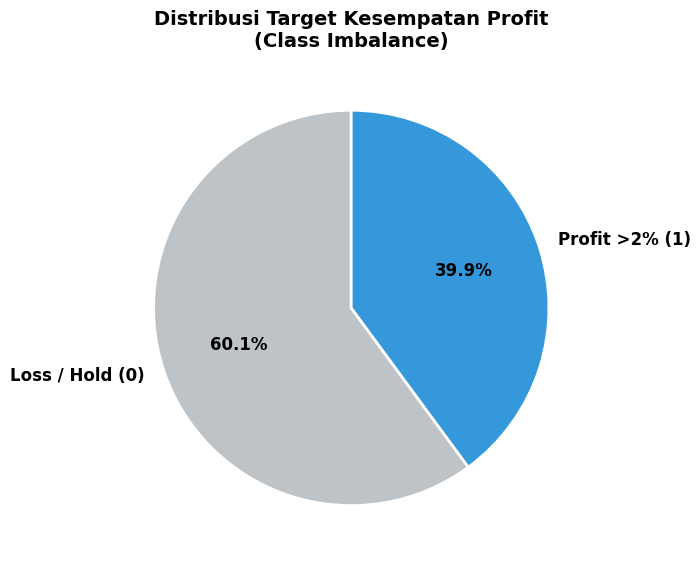

In [4]:
bg_color = 'white'
text_color = 'black'
slice_colors = ['#bdc3c7', '#3498db']

plt.figure(figsize=(7, 7), facecolor=bg_color)

target_counts = df['TARGET'].value_counts()
labels = ['Loss / Hold (0)', 'Profit >2% (1)']

plt.pie(target_counts, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=slice_colors, 
        textprops={'color': text_color, 'fontsize': 12, 'weight':'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title('Distribusi Target Kesempatan Profit\n(Class Imbalance)', color=text_color, fontsize=14, weight='bold', pad=10)

plt.tight_layout()
plt.savefig('plots/eda_target_distribution_white.png', dpi=300, bbox_inches='tight')
plt.show()

#### LIQUID FILTER

In [5]:
initial_len = len(df)
df_filtered = df[df['avg_tx_value'] > Config.MIN_VOLUME_IDR].copy()

if len(df_filtered) == 0:
    print(f"Filter {Config.MIN_VOLUME_IDR:,.0f} terlalu ketat, gunakan semua data.")
else:
    df = df_filtered
    print(f"{initial_len - len(df)} baris dihapus.")

print(f"Data setelah filter: {len(df)} baris")

622 baris dihapus.
Data setelah filter: 11761 baris


#### SPLIT DATA

In [6]:
# CEK KOLOM DATE ADALAH DATETIME
df['date'] = pd.to_datetime(df['date'])

dates = df['date'].sort_values().unique()
split_idx = int(len(dates) * Config.TEST_SPLIT_RATIO)
split_date = dates[split_idx]

df_train = df[df['date'] < split_date].copy()
df_test  = df[df['date'] >= split_date].copy()

print(f"Cutoff date: {pd.to_datetime(split_date).strftime('%Y-%m-%d')}")
print(f"Train: {len(df_train)} baris ({df_train['date'].min().strftime('%Y-%m-%d')} s/d {df_train['date'].max().strftime('%Y-%m-%d')})")
print(f"Test : {len(df_test)} baris ({df_test['date'].min().strftime('%Y-%m-%d')} s/d {df_test['date'].max().strftime('%Y-%m-%d')})")

if len(df_train) == 0 or len(df_test) == 0:
    raise ValueError("Data train/test kosong! Cek rasio split.")

Cutoff date: 2025-12-23
Train: 9221 baris (2025-11-07 s/d 2025-12-22)
Test : 2540 baris (2025-12-23 s/d 2026-01-08)


In [7]:
features = [
    'net_vol', 'net_vol_5d_sum', 'net_vol_20d_sum',
    'rsi_14', 'atr_10d',
    'price_vs_vwap', 'price_vs_ma20', 'trend_strong',
    'interaction_vol_atr',
    'market_net_ratio', 'market_ma5',
    'is_foreign_stock', 'float_risk', 'strong_controller'
]

In [8]:
available_features = [f for f in features if f in df.columns]
print(f"{len(available_features)} fitur: {available_features}")

X_train = df_train[available_features].values
y_train = df_train['TARGET'].values
X_test = df_test[available_features].values
y_test = df_test['TARGET'].values

14 fitur: ['net_vol', 'net_vol_5d_sum', 'net_vol_20d_sum', 'rsi_14', 'atr_10d', 'price_vs_vwap', 'price_vs_ma20', 'trend_strong', 'interaction_vol_atr', 'market_net_ratio', 'market_ma5', 'is_foreign_stock', 'float_risk', 'strong_controller']


### TRAINING MODEL

In [9]:
print("\nCross Validation (5 folds)...")

tscv = TimeSeriesSplit(n_splits=Config.N_FOLDS)

oof_pred = np.zeros(len(X_train))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]
    
    # --- LightGBM ---
    lgb_params = {
        'n_estimators': 500,
        'learning_rate': 0.03,
        'num_leaves': 31,
        'random_state': Config.RANDOM_STATE,
        'class_weight': 'balanced',
        'verbose': -1
    }
    model_lgb = lgb.LGBMClassifier(**lgb_params)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    
    # --- CatBoost ---
    model_cat = CatBoostClassifier(
        iterations=500,
        learning_rate=0.03,
        depth=6,
        auto_class_weights='Balanced',
        verbose=0,
        random_state=Config.RANDOM_STATE,
        allow_writing_files=False
    )
    model_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
    
    # --- Random Forest ---
    model_rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced',
        n_jobs=-1,
        random_state=Config.RANDOM_STATE
    )
    model_rf.fit(X_tr, y_tr)
    
    p_lgb = model_lgb.predict_proba(X_val)[:, 1]
    p_cat = model_cat.predict_proba(X_val)[:, 1]
    p_rf = model_rf.predict_proba(X_val)[:, 1]
    
    # Ensemble
    p_val = 0.4 * p_lgb + 0.4 * p_cat + 0.2 * p_rf
    oof_pred[val_idx] = p_val
    
    auc_val = roc_auc_score(y_val, p_val)
    fold_scores.append(auc_val)
    print(f"Fold {fold}: AUC = {auc_val:.4f}")

print(f"Rata-rata AUC CV: {np.mean(fold_scores):.4f}")


Cross Validation (5 folds)...
Fold 1: AUC = 0.6782
Fold 2: AUC = 0.7083
Fold 3: AUC = 0.6401
Fold 4: AUC = 0.6600
Fold 5: AUC = 0.6097
Rata-rata AUC CV: 0.6593


#### THRESHOLD OPTIMATION

In [10]:
best_thresh = 0.5
best_fbeta = 0
thresholds = np.arange(0.4, 0.9, 0.02)

for thresh in thresholds:
    pred_bin = (oof_pred > thresh).astype(int)
    if pred_bin.sum() > 20:
        fbeta = fbeta_score(y_train, pred_bin, beta=0.5)
        if fbeta > best_fbeta:
            best_fbeta = fbeta
            best_thresh = thresh

print(f"Threshold optimal: {best_thresh:.2f} (F0.5 = {best_fbeta:.4f})")

Threshold optimal: 0.52 (F0.5 = 0.5026)


#### FINAL TRAIN

In [11]:
# --- LightGBM ---
final_lgb = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=40,
    random_state=Config.RANDOM_STATE,
    class_weight='balanced',
    verbose=-1
)
final_lgb.fit(X_train, y_train)

# --- CatBoost ---
final_cat = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced',
    verbose=0,
    random_state=Config.RANDOM_STATE,
    allow_writing_files=False
)
final_cat.fit(X_train, y_train)

# --- Random Forest ---
final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    n_jobs=-1,
    random_state=Config.RANDOM_STATE
)
final_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### EVALUATION

In [12]:
p_lgb_test = final_lgb.predict_proba(X_test)[:, 1]
p_cat_test = final_cat.predict_proba(X_test)[:, 1]
p_rf_test = final_rf.predict_proba(X_test)[:, 1]

w_lgb, w_cat, w_rf = 0.25, 0.50, 0.25
p_ensemble_test = w_lgb * p_lgb_test + w_cat * p_cat_test + w_rf * p_rf_test

auc_test = roc_auc_score(y_test, p_ensemble_test)
print(f"ENSEMBLE AUC (TEST): {auc_test:.4f}")

y_pred_test = (p_ensemble_test > best_thresh).astype(int)

ENSEMBLE AUC (TEST): 0.6490


In [23]:
print("\n📊 CLASSIFICATION REPORT (TEST SET):")
print(classification_report(y_test, y_pred_test, target_names=['No Profit', 'Profit >2%']))

precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)

print(f"\n📈 BUSINESS METRICS:")
print(f"   Total sinyal BUY   : {y_pred_test.sum()}")
print(f"   True Positive      : {(y_pred_test & y_test).sum()}")
print(f"   False Positive     : {((y_pred_test == 1) & (y_test == 0)).sum()}")
print(f"   Precision          : {precision_test:.2%}")
print(f"   Recall             : {recall_test:.2%}")


📊 CLASSIFICATION REPORT (TEST SET):
              precision    recall  f1-score   support

   No Profit       0.59      0.60      0.60      1221
  Profit >2%       0.63      0.61      0.62      1319

    accuracy                           0.61      2540
   macro avg       0.61      0.61      0.61      2540
weighted avg       0.61      0.61      0.61      2540


📈 BUSINESS METRICS:
   Total sinyal BUY   : 1292
   True Positive      : 809
   False Positive     : 483
   Precision          : 62.62%
   Recall             : 61.33%


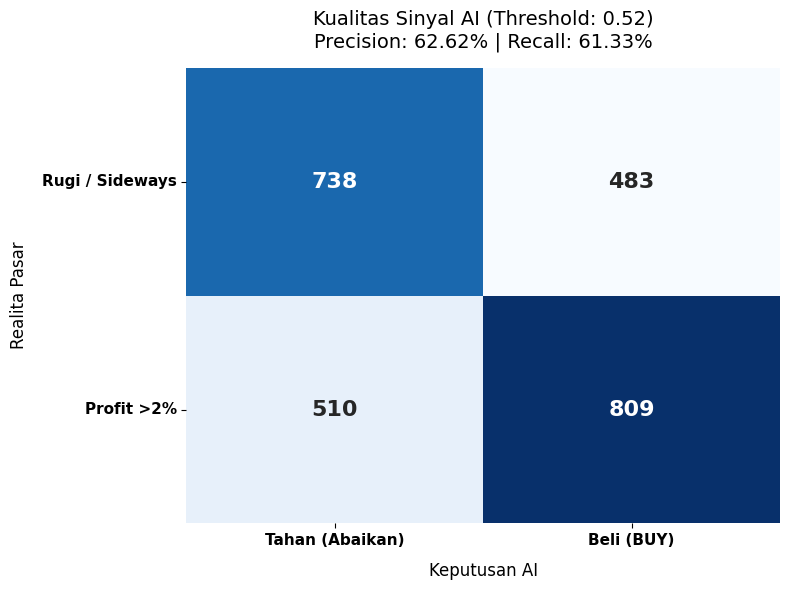

In [14]:
def plot_business_confusion_matrix(y_true, y_prob, threshold, save_path='plots/1_business_cm.png'):
    y_pred = (y_prob > threshold).astype(int)
    
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                annot_kws={"size": 16, "weight": "bold"})
    
    plt.title(f'Kualitas Sinyal AI (Threshold: {threshold:.2f})\nPrecision: {precision:.2%} | Recall: {recall:.2%}', 
              fontsize=14, pad=15)
    plt.xlabel('Keputusan AI', fontsize=12, labelpad=10)
    plt.ylabel('Realita Pasar', fontsize=12, labelpad=10)
    
    plt.xticks([0.5, 1.5], ['Tahan (Abaikan)', 'Beli (BUY)'], fontsize=11, weight='bold')
    plt.yticks([0.5, 1.5], ['Rugi / Sideways', 'Profit >2%'], fontsize=11, weight='bold', rotation=0)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    
plot_business_confusion_matrix(
    y_true=y_test, 
    y_prob=p_ensemble_test, 
    threshold=best_thresh
)

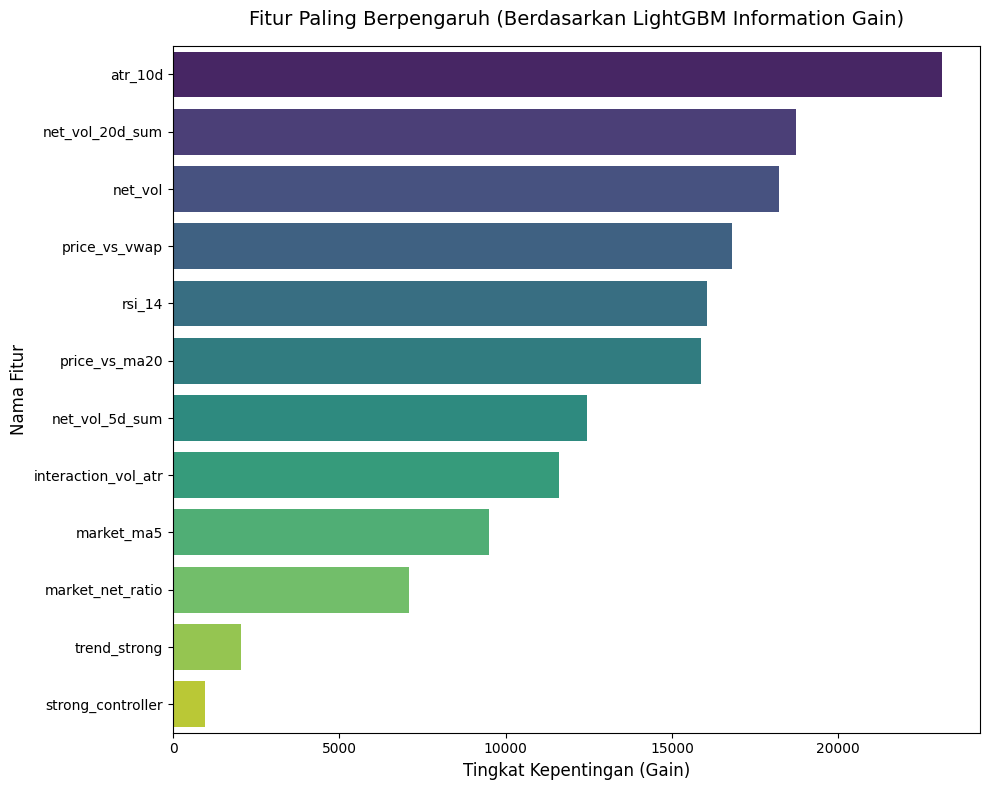

In [15]:
def plot_feature_importance(model_lgb, features_list, save_path='plots/2_feature_importance.png'):
    gain_imp = model_lgb.booster_.feature_importance(importance_type='gain')
    importance_df = pd.DataFrame({
        'Feature': features_list,
        'Importance': gain_imp
    }).sort_values(by='Importance', ascending=False).head(12)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
    
    plt.title('Fitur Paling Berpengaruh (Berdasarkan LightGBM Information Gain)', fontsize=14, pad=15)
    plt.xlabel('Tingkat Kepentingan (Gain)', fontsize=12)
    plt.ylabel('Nama Fitur', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_feature_importance(
    model_lgb=final_lgb, 
    features_list=available_features
)

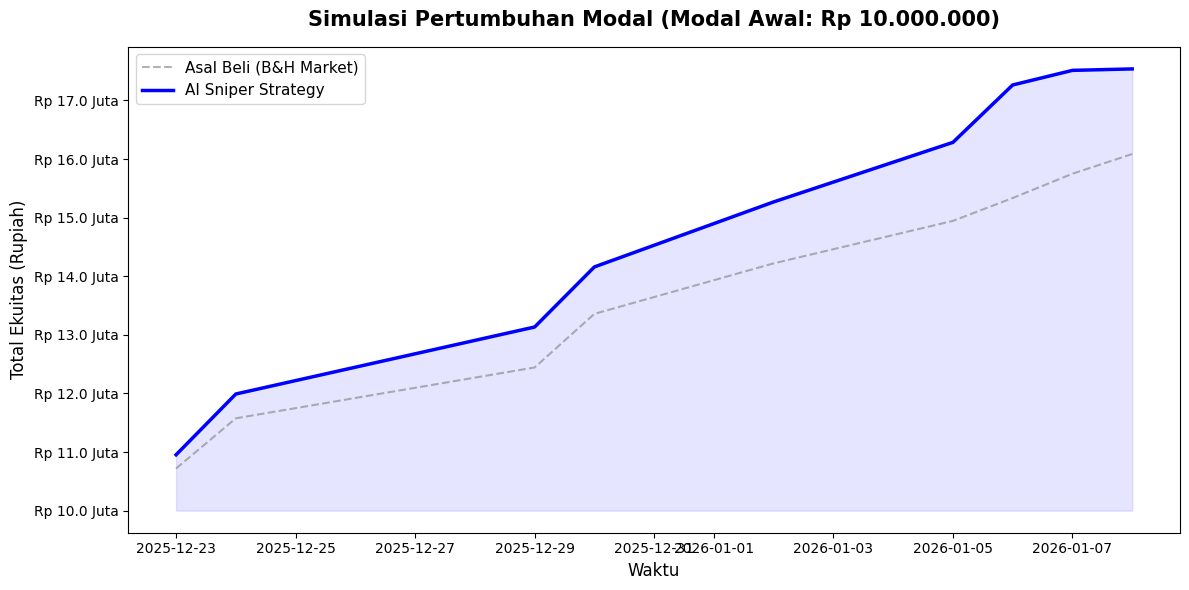

In [16]:
from matplotlib.ticker import FuncFormatter

def plot_equity_curve(df_test, y_prob, threshold, cost_per_trade=0.005, initial_capital=10000000, save_path='plots/3_equity_curve.png'):
    df_viz = df_test.copy()
    df_viz['signal'] = (y_prob > threshold).astype(int)
    
    df_viz['ret_clean'] = df_viz['return_10d'].clip(lower=-0.2, upper=0.5)

    df_viz['strat_ret'] = np.where(df_viz['signal'] == 1, df_viz['ret_clean'] - cost_per_trade, 0)
    
    daily_market = df_viz.groupby('date')['ret_clean'].mean()
    daily_strat = df_viz[df_viz['signal'] == 1].groupby('date')['strat_ret'].mean()
    
    daily_strat = daily_strat.reindex(daily_market.index).fillna(0)
    
    cum_market = (1 + daily_market).cumprod()
    cum_strategy = (1 + daily_strat).cumprod()
    
    rupiah_market = cum_market * initial_capital
    rupiah_strategy = cum_strategy * initial_capital
    
    plt.figure(figsize=(12, 6))
    plt.plot(rupiah_market.index, rupiah_market.values, label='Asal Beli (B&H Market)', color='gray', alpha=0.6, linestyle='--')
    plt.plot(rupiah_strategy.index, rupiah_strategy.values, label='AI Sniper Strategy', color='blue', lw=2.5)
    
    plt.title('Simulasi Pertumbuhan Modal (Modal Awal: Rp 10.000.000)', fontsize=15, pad=15, weight='bold')
    plt.ylabel('Total Ekuitas (Rupiah)', fontsize=12)
    plt.xlabel('Waktu', fontsize=12)
    
    def rupiah_formatter(x, pos):
        return f'Rp {x/1e6:.1f} Juta'
    plt.gca().yaxis.set_major_formatter(FuncFormatter(rupiah_formatter))
    
    plt.legend(loc='upper left', fontsize=11)
    plt.fill_between(rupiah_strategy.index, rupiah_strategy.values, initial_capital, 
                     where=(rupiah_strategy.values > initial_capital), color='blue', alpha=0.1)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    
    plt.show()
    
plot_equity_curve(
    df_test=df_test, 
    y_prob=p_ensemble_test, 
    threshold=best_thresh,
    initial_capital=10000000
)

### SAVE MODEL

In [17]:
metadata = {
    'model_lgb': final_lgb,
    'model_cat': final_cat,
    'model_rf': final_rf,
    'features': available_features,
    'threshold': best_thresh,
    'weights': {'lgb': w_lgb, 'cat': w_cat, 'rf': w_rf},
    'auc_test': auc_test,
    'precision_test': precision_test,
    'recall_test': recall_test,
    'config': {
        'TARGET_MIN_RETURN': Config.TARGET_MIN_RETURN,
        'MIN_VOLUME_IDR': Config.MIN_VOLUME_IDR,
        'split_date': split_date
    }
}

os.makedirs("models", exist_ok=True)
model_path = "models/model_v8_final.pkl"
joblib.dump(metadata, model_path)
print(f"Model saved: {model_path}")

Model saved: models/model_v8_final.pkl
